In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten
from keras.callbacks import EarlyStopping

## Load Dataset

In [2]:
((X_train, y_train),(X_test, y_test))=keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Checking shape
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


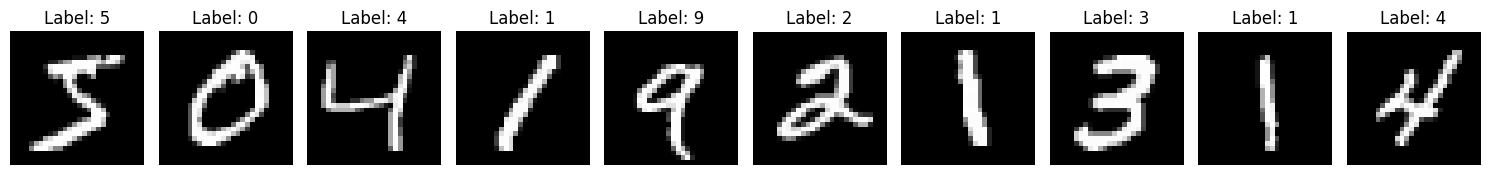

In [4]:
#visualize the data
fig, ax=plt.subplots(1,10, figsize=(15, 2))
for i in range(10):
    ax[i].imshow(X_train[i], cmap="grey")
    ax[i].set_title(f"Label: {y_train[i]}")
    ax[i].axis("off")
plt.tight_layout()
plt.show()

## Data Preprocessing

### Normalization

In [5]:
X_train=X_train/255
X_test=X_test/255

### Reshaping
- A CNN expects its input to have a **channel dimension** in addition to the image height and width.
- For datasets like **MNIST**, 1 colour channel is sufficient, but for images like **RGB**, they require <u>3 different channels per colour</u>.
- For coloured images (like RGB), the reshape would be like (28, 28, 3).

In [6]:
# -1 tells NumPy to infer the number of images automatically
X_train=X_train.reshape(-1,28,28,1)
X_test=X_test.reshape(-1,28,28,1)

## Defining the Architecture of CNN Models

In [28]:
# defining early stopping strategy
early_stopping=EarlyStopping(
    monitor='val_loss',
    patience=5,  # Number of epochs to wait for improvement before stopping
    restore_best_weights=True, # Roll back model weights to the best epoch
    start_from_epoch=5 #  Number of epochs to wait before starting to monitor improvement
)

### Model1 

In [17]:
model1=Sequential()

model1.add(Conv2D(filters=32, kernel_size=(4,4), input_shape=(28,28,1), activation='relu')) #gen activation map per filter
model1.add(MaxPool2D(pool_size=(2,2)))
model1.add(Flatten())
model1.add(Dense(128, activation='relu'))
# model1.add(Dropout=0.5)
model1.add(Dense(10, activation='softmax'))

In [18]:
model1.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 25, 25, 32)     │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591,786 (2.26 MB)

 Trainable params: 591,786 (2.26 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model1.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [29]:
hist_model1=model1.fit(X_train,y_train,batch_size=32,epochs=20,
                       verbose=1,validation_split=0.2, callbacks=[early_stopping])

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9929 - loss: 0.0225 - val_accuracy: 0.9843 - val_loss: 0.0569
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9960 - loss: 0.0122 - val_accuracy: 0.9873 - val_loss: 0.0524
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9974 - loss: 0.0081 - val_accuracy: 0.9847 - val_loss: 0.0606
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9977 - loss: 0.0071 - val_accuracy: 0.9847 - val_loss: 0.0695
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9977 - loss: 0.0062 - val_accuracy: 0.9863 - val_loss: 0.0606
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9989 - loss: 0.0035 - val_accuracy: 0.9866 - val_loss: 0.0647
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9980 - loss: 0.0056 - val_accuracy: 0.9851 - val_loss: 0.0691
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9984 - loss: 0.0043 - 

In [30]:
losses_model1=pd.DataFrame(model1.history.history)
losses_model1

,accuracy,loss,val_accuracy,val_loss
0,0.992896,0.022502,0.984250,0.056892
1,0.996021,0.012172,0.987333,0.052430
2,0.997375,0.008116,0.984750,0.060588
3,0.997729,0.007050,0.984667,0.069488
4,0.997667,0.006239,0.986333,0.060624
5,0.998896,0.003475,0.986583,0.064683
6,0.998042,0.005638,0.985083,0.069059
7,0.998375,0.004275,0.987500,0.070754
8,0.998812,0.003780,0.987333,0.064257
9,0.998896,0.002998,0.987000,0.069577


### Model2

In [31]:
model2=Sequential()

model2.add(Conv2D(filters=32, kernel_size=(4,4), input_shape=(28,28,1), activation='relu')) #gen activation map per filter
model2.add(MaxPool2D(pool_size=(2,2)))
model2.add(Conv2D(filters=64, kernel_size=(4,4), input_shape=(28,28,1), activation='relu')) #find more complex features
model2.add(MaxPool2D(pool_size=(2,2)))
model2.add(Flatten())
model2.add(Dense(128, activation='relu'))
# model2.add(Dropout=0.5)
model2.add(Dense(10, activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
model2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 25, 25, 32)     │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 9, 9, 64)       │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,866 (647.91 KB)

 Trainable params: 165,866 (647.91 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
model2.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [34]:
hist_model2=model2.fit(X_train,y_train,batch_size=32,epochs=20,
                       verbose=1,validation_split=0.2, callbacks=[early_stopping])

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9543 - loss: 0.1493 - val_accuracy: 0.9831 - val_loss: 0.0565
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9856 - loss: 0.0480 - val_accuracy: 0.9851 - val_loss: 0.0532
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9901 - loss: 0.0326 - val_accuracy: 0.9847 - val_loss: 0.0543
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9921 - loss: 0.0245 - val_accuracy: 0.9886 - val_loss: 0.0389
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9939 - loss: 0.0198 - val_accuracy: 0.9909 - val_loss: 0.0378
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9950 - loss: 0.0140 - val_accuracy: 0.9894 - val_loss: 0.0486
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9963 - loss: 0.0109 - val_accuracy: 0.9902 - val_loss: 0.0447
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9965 - loss: 0.0097 - 

In [35]:
losses_model2=pd.DataFrame(model2.history.history)
losses_model2

,accuracy,loss,val_accuracy,val_loss
0,0.954313,0.149318,0.983083,0.056511
1,0.985604,0.047951,0.985083,0.053225
2,0.990062,0.032554,0.984667,0.054252
3,0.992083,0.024459,0.988583,0.038920
4,0.993875,0.019758,0.990917,0.037754
5,0.995000,0.014016,0.989417,0.048617
6,0.996333,0.010851,0.990250,0.044695
7,0.996479,0.009651,0.989333,0.046249
8,0.997042,0.008329,0.990083,0.048985
9,0.996687,0.009521,0.990417,0.047358


## Saving best models

In [38]:
model1.save("cnn_model1.keras")
print("model1 is saved as 'cnn_model1.kears'")
model2.save("cnn_model2.keras")
print("model2 is saved as 'cnn_model2.kears'")

model1 is saved as 'cnn_model1.kears'
model2 is saved as 'cnn_model2.kears'


## Learning curve of all models

In [ ]:
fig, ax =plt.subplots(2,2)
ax[0].plot(model1.history.history['accuracy'], label='Training accuracy')
ax[0].plot(model1.history.history['val_accuracy'])
ax[1].plot(model2.history.history['accuracy'], label='Training accuracy')

## TO DO
- add early stopping with increased epochs

---
- Compare the results to ann model

## Q/A

- Why use 32 filters?
    - 32 feature generations, 32 activation/feature maps; if we go for only 1 filter, then it captures only 1 feature. That's why we use a number of features which may capture different features.
    
- Why do later layers often have more filters?
    - The later layers are use to combine the features extracted by their previous layers.
    - As features become more complex, the network benefits from having more filters to represent a richer variety of patterns.
    - After each pooling layer, the spatial dimensions shrink.
    - Since each feature map becomes smaller, the computational cost per filter decreases. This makes it feasible to increase the number of filters while keeping the total computation manageable.

- kernel_size:
    - Also known as filter_size or receptive_field_size.
    - It represents the spatial dimensions (height and width) of the filter applied during a convolution operation.
    - These kernels are essentially matrices of learnable weights that glide across an input image or a previous feature map to detect specific visual features, such as edges, loops, or complex shapes like an eye
    - A kernel's depth will always extend through the entire depth of the input volume. For example, if you apply a 6x6 kernel to an RGB-coloured image, the kernel will have a depth of 3, meaning the neuron contains 108 individual weights (6x6x3)

- pool_size:
    - It defines the spatial dimensions of the window used to downsample a feature map within a pooling layer
    - Because pooling is highly destructive to the underlying data, utilizing a pool size larger than 3x3 will usually lead to a significant decrease in the model's performance

- Does I need to add dropout?
    - Dropout is a regularization technique that randomly "turns off" a fraction of neurons during training.
    - for `dropout(0.5)` about 50% of the neurons in that layer are randomly ignored during **each training step**. This forces the network to learn more robust features instead of relying too heavily on specific neurons.